In [230]:
import numpy as np
import pandas as pd
from random import seed
from random import random
import matplotlib.pyplot as plt
import os
import time

In [705]:
mplt_prt = [2.0, 1.3, 1.0, 0.87, 0.47, 0.23]
mplt_mod = [2.9, 1.6, 1.3, 1.1]
mptl_rec = [1.0, 0.95, 0.9, 0.75]

p = 0.03

In [709]:
porte = 1
modalidade = 2

p0 = mplt_prt[porte - 1] * mplt_mod[modalidade - 1] * p
q0 = 1 - p0

p30 = 0.40 * mptl_rec[modalidade - 1]
p60 = 0.55 * mptl_rec[modalidade - 1]
p90 = 0.63 * mptl_rec[modalidade - 1]
p120 = 0.75 * mptl_rec[modalidade - 1]
p150 = 0.80 * mptl_rec[modalidade - 1]
p180 = 0.85
p270 = 0.90
p300 = 0.95
p330 = 0.975
p360 = 0.995
prej = 1.000



In [710]:
P = np.array([[q0      , p0   , 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00 ],
              [1 - p30 , 0.00, p30  , 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00 ],
              [1 - p60 , 0.00, 0.00, p60  , 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00 ],
              [1 - p90 , 0.00, 0.00, 0.00, p90 ,  0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00 ],
              [1 - p120, 0.00, 0.00, 0.00, 0.00, p120 , 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00 ],
              [1 - p150, 0.00, 0.00, 0.00, 0.00, 0.00, p150 , 0.00, 0.00, 0.00, 0.00, 0.00, 0.00 ],
              [1 - p180, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, p180  , 0.00, 0.00, 0.00, 0.00, 0.00 ],
              [1 - p180, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, p180  , 0.00, 0.00, 0.00, 0.00 ],
              [1 - p180, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, p180  , 0.00, 0.00, 0.00 ],
              [1 - p270, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, p270  , 0.00, 0.00 ],
              [1 - p300, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, p300  , 0.00 ],
              [1 - p330, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00  , p330 ],
              [0.00    , 0.00, 0.00, 0.00, 0.00, 0.000, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00 , 1.00]])
        
stateChangeHist= np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])

In [713]:
%%time

lista = []
np.seterr(divide='ignore', invalid='ignore')
for i in range(1000):
    meses = 60   
    state=np.array([[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
    currentState=0
    stateHist=state
    dfStateHist=pd.DataFrame(state)
    distr_hist = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
    seed(4)

    # Simulate from multinomial distribution
    def simulate_multinomial(vmultinomial):
        r=np.random.uniform(0.0, 1.0)
        CS=np.cumsum(vmultinomial)
        CS=np.insert(CS,0,0)
        m=(np.where(CS<r))[0]
        nextState=m[len(m)-1]
        return nextState

    for x in range(meses):
        currentRow=np.ma.masked_values((P[currentState]), 0.0)
        nextState=simulate_multinomial(currentRow)
      # Keep track of state changes
        stateChangeHist[currentState,nextState]+=1
      # Keep track of the state vector itself
        state=np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
        state[0,nextState]=1.0
      # Keep track of state history
        stateHist=np.append(stateHist,state,axis=0)
        currentState=nextState
      # calculate the actual distribution over the 3 states so far
        totals=np.sum(stateHist,axis=0)
        gt=np.sum(totals)
        distrib=totals/gt
        distrib=np.reshape(distrib,(1, 13))
        distr_hist=np.append(distr_hist,distrib,axis=0)

    #print(distrib)
    P_hat=stateChangeHist/stateChangeHist.sum(axis=1)[:,None]
    # Check estimated state transition probabilities based on history so far:
    #print(P_hat)
    dfDistrHist = pd.DataFrame(distr_hist)
    # Plot the distribution as the simulation progresses over time

    carteira = dfDistrHist[dfDistrHist.index == last][0] + dfDistrHist[dfDistrHist.index == last][1] + \
    dfDistrHist[dfDistrHist.index == last][2] + dfDistrHist[dfDistrHist.index == last][3] + \
    dfDistrHist[dfDistrHist.index == last][4] + dfDistrHist[dfDistrHist.index == last][5] + \
    dfDistrHist[dfDistrHist.index == last][6] + dfDistrHist[dfDistrHist.index == last][7] + \
    dfDistrHist[dfDistrHist.index == last][8] + dfDistrHist[dfDistrHist.index == last][9] + \
    dfDistrHist[dfDistrHist.index == last][10] + dfDistrHist[dfDistrHist.index == last][11]

    inad = dfDistrHist[dfDistrHist.index == last][3] + \
    dfDistrHist[dfDistrHist.index == last][4] + dfDistrHist[dfDistrHist.index == last][5] + \
    dfDistrHist[dfDistrHist.index == last][6] + dfDistrHist[dfDistrHist.index == last][7] + \
    dfDistrHist[dfDistrHist.index == last][8] + dfDistrHist[dfDistrHist.index == last][9] + \
    dfDistrHist[dfDistrHist.index == last][10] + dfDistrHist[dfDistrHist.index == last][11]

    lista.append(inad/carteira)
np.mean(lista)

Wall time: 23.2 s


0.0686885312818005

[[0.83606557 0.04918033 0.03278689 0.03278689 0.03278689 0.01639344
  0.         0.         0.         0.         0.         0.
  0.        ]]
[[0.94632877 0.05367123 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.62218999 0.         0.37781001 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.46601942 0.         0.         0.53398058 0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.37132353 0.         0.         0.         0.62867647 0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.31547619 0.         0.         0.         0.         0.68452381
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.23893805 0.         0.         0.         0.         0.
  0.76106195 0.         0.         0.         0.         0.
  0.        ]
 [0.1        0.         0.         0.        

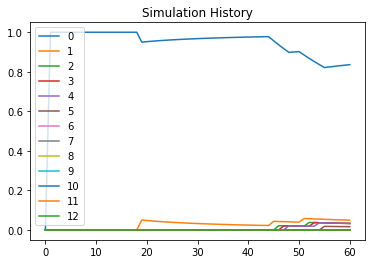

In [691]:

#P = np.array([[0.2, 0.7, 0.1],
#              [0.9, 0.0, 0.1],
#              [0.2, 0.8, 0.0]])
#

#stateChangeHist= np.array([[0.0, 0.0,  0.0],
#                           [0.0, 0.0,  0.0],
#                           [0.0, 0.0,  0.0]])
#

state=np.array([[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
currentState=0
stateHist=state
dfStateHist=pd.DataFrame(state)
distr_hist = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
seed(4)

# Simulate from multinomial distribution
def simulate_multinomial(vmultinomial):
    r=np.random.uniform(0.0, 1.0)
    CS=np.cumsum(vmultinomial)
    CS=np.insert(CS,0,0)
    m=(np.where(CS<r))[0]
    nextState=m[len(m)-1]
    return nextState

for x in range(60):
    currentRow=np.ma.masked_values((P[currentState]), 0.0)
    nextState=simulate_multinomial(currentRow)
  # Keep track of state changes
    stateChangeHist[currentState,nextState]+=1
  # Keep track of the state vector itself
    state=np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
    state[0,nextState]=1.0
  # Keep track of state history
    stateHist=np.append(stateHist,state,axis=0)
    currentState=nextState
  # calculate the actual distribution over the 3 states so far
    totals=np.sum(stateHist,axis=0)
    gt=np.sum(totals)
    distrib=totals/gt
    distrib=np.reshape(distrib,(1, 13))
    distr_hist=np.append(distr_hist,distrib,axis=0)
    
print(distrib)
P_hat=stateChangeHist/stateChangeHist.sum(axis=1)[:,None]
# Check estimated state transition probabilities based on history so far:
print(P_hat)
dfDistrHist = pd.DataFrame(distr_hist)
# Plot the distribution as the simulation progresses over time

dfDistrHist.plot(title="Simulation History")
plt.show()

In [199]:
dfDistrHist

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,0.684211,0.175439,0.052632,0.052632,0.035088,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,0.672414,0.172414,0.068966,0.051724,0.034483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58,0.677966,0.169492,0.067797,0.050847,0.033898,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59,0.683333,0.166667,0.066667,0.050000,0.033333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [200]:
last = 60

carteira = dfDistrHist[dfDistrHist.index == last][0] + dfDistrHist[dfDistrHist.index == last][1] + \
dfDistrHist[dfDistrHist.index == last][2] + dfDistrHist[dfDistrHist.index == last][3] + \
dfDistrHist[dfDistrHist.index == last][4] + dfDistrHist[dfDistrHist.index == last][5] + \
dfDistrHist[dfDistrHist.index == last][6] + dfDistrHist[dfDistrHist.index == last][7] + \
dfDistrHist[dfDistrHist.index == last][8] + dfDistrHist[dfDistrHist.index == last][9] + \
dfDistrHist[dfDistrHist.index == last][10] + dfDistrHist[dfDistrHist.index == last][11]

inad = dfDistrHist[dfDistrHist.index == last][3] + \
dfDistrHist[dfDistrHist.index == last][4] + dfDistrHist[dfDistrHist.index == last][5] + \
dfDistrHist[dfDistrHist.index == last][6] + dfDistrHist[dfDistrHist.index == last][7] + \
dfDistrHist[dfDistrHist.index == last][8] + dfDistrHist[dfDistrHist.index == last][9] + \
dfDistrHist[dfDistrHist.index == last][10] + dfDistrHist[dfDistrHist.index == last][11]

inad/carteira

60    0.081967
dtype: float64

Porte 2 - Modalidade 1